# 1.0 — Data Loading & Exploration

Download the Construction Site Safety dataset from Roboflow, explore its structure, visualize samples, and analyze class distribution.

**Clean architecture rule:** all data-loading logic lives in `algear.dataset`; this notebook only orchestrates and visualizes.

In [11]:
# Reload module after edits
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Download dataset from Roboflow

Requires `ROBOFLOW_API_KEY` in `.env` (see `.env.example`).

In [12]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from algear.config import (
    PROJ_ROOT, RAW_DATA_DIR, ROBOFLOW_DIR,
    ROBOFLOW_API_KEY, ROBOFLOW_WORKSPACE, ROBOFLOW_PROJECT, ROBOFLOW_VERSION,
)
from algear.dataset import download_roboflow

In [13]:
if not ROBOFLOW_API_KEY:
    raise ValueError(
        "ROBOFLOW_API_KEY is empty. Add it to the .env file at the project root."
        "\nGet your key at https://app.roboflow.com/settings/api"
    )

print(f"Workspace : {ROBOFLOW_WORKSPACE}")
print(f"Project   : {ROBOFLOW_PROJECT}")
print(f"Version   : {ROBOFLOW_VERSION}")
print(f"Target    : {ROBOFLOW_DIR}")

Workspace : roboflow-100
Project   : construction-safety-gsnvb
Version   : 1
Target    : D:\AlGear\data\raw\construction-safety-gsnvb


In [14]:
dataset = download_roboflow(output_dir=ROBOFLOW_DIR)

2026-06-22 15:45:40.234 | INFO     | algear.dataset:download_roboflow:33 - Downloading roboflow-100/construction-safety-gsnvb v1 to D:\AlGear\data\raw\construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...
2026-06-22 15:45:45.079 | SUCCESS  | algear.dataset:download_roboflow:37 - Dataset downloaded to D:\AlGear\data\raw\construction-safety-gsnvb


## 2. Inspect dataset structure

In [15]:
def show_tree(path: Path, max_depth: int = 2):
    for child in sorted(path.rglob("*")):
        rel = child.relative_to(path)
        depth = len(rel.parts)
        if depth <= max_depth:
            prefix = "  " * depth + "\u2514\u2500 "
            print(f"{prefix}{rel.parts[-1]}{"/" if child.is_dir() else ""}")

show_tree(ROBOFLOW_DIR)

  └─ data.yaml
  └─ README.dataset.txt
  └─ README.roboflow.txt
  └─ test/
    └─ images/
    └─ labels/
  └─ train/
    └─ images/
    └─ labels/
  └─ valid/
    └─ images/
    └─ labels/


In [16]:
import yaml

data_yaml = ROBOFLOW_DIR / "data.yaml"
with open(data_yaml) as f:
    cfg = yaml.safe_load(f)

print("Classes:")
for i, name in enumerate(cfg["names"]):
    print(f"  {i}: {name}")

Classes:
  0: helmet
  1: no-helmet
  2: no-vest
  3: person
  4: vest


In [17]:
def count_images_labels(split: str) -> dict:
    img_dir = ROBOFLOW_DIR / split / "images"
    lbl_dir = ROBOFLOW_DIR / split / "labels"
    images = sorted(img_dir.glob("*")) if img_dir.exists() else []
    labels = sorted(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    return {"images": len(images), "labels": len(labels), "path": str(img_dir)}

for split in ["train", "valid", "test"]:
    info = count_images_labels(split)
    print(f"{split:>6s}: {info['images']:>4d} images, {info['labels']:>4d} labels")
    print(f"{'':>6s}  {info['path']}")

 train:  997 images,  997 labels
        D:\AlGear\data\raw\construction-safety-gsnvb\train\images
 valid:  119 images,  119 labels
        D:\AlGear\data\raw\construction-safety-gsnvb\valid\images
  test:   90 images,   90 labels
        D:\AlGear\data\raw\construction-safety-gsnvb\test\images


## 3. Visualise sample images with annotations

In [18]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from algear.config import ROBOFLOW_DIR

# Load class names
with open(ROBOFLOW_DIR / "data.yaml") as f:
    class_names = yaml.safe_load(f)["names"]

COLORS = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe",
]

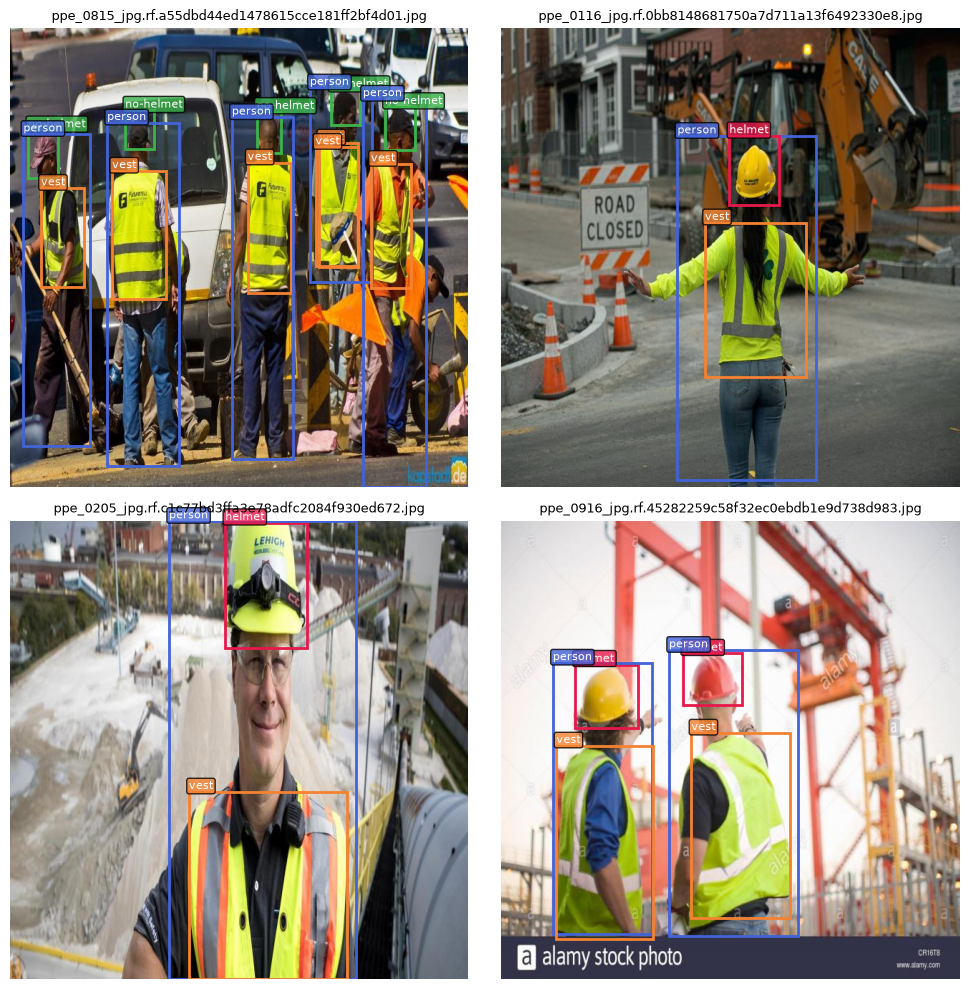

In [19]:
def show_random_samples(split: str = "train", n: int = 4):
    img_dir = ROBOFLOW_DIR / split / "images"
    lbl_dir = ROBOFLOW_DIR / split / "labels"
    images = sorted(img_dir.glob("*"))
    if not images:
        print(f"No images found in {img_dir}")
        return

    samples = random.sample(images, min(n, len(images)))
    fig, axes = plt.subplots(2, n // 2 if n > 1 else 1, figsize=(5 * (n // 2), 10))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, img_path in zip(axes, samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        ax.imshow(img)

        label_path = lbl_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    cls_id, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h

                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor=COLORS[cls_id % len(COLORS)],
                        facecolor="none",
                    )
                    ax.add_patch(rect)
                    ax.text(
                        x1, y1 - 4, class_names[cls_id],
                        fontsize=8, color="white",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor=COLORS[cls_id % len(COLORS)], alpha=0.8),
                    )

        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_random_samples("train", n=4)

## 4. Class distribution analysis

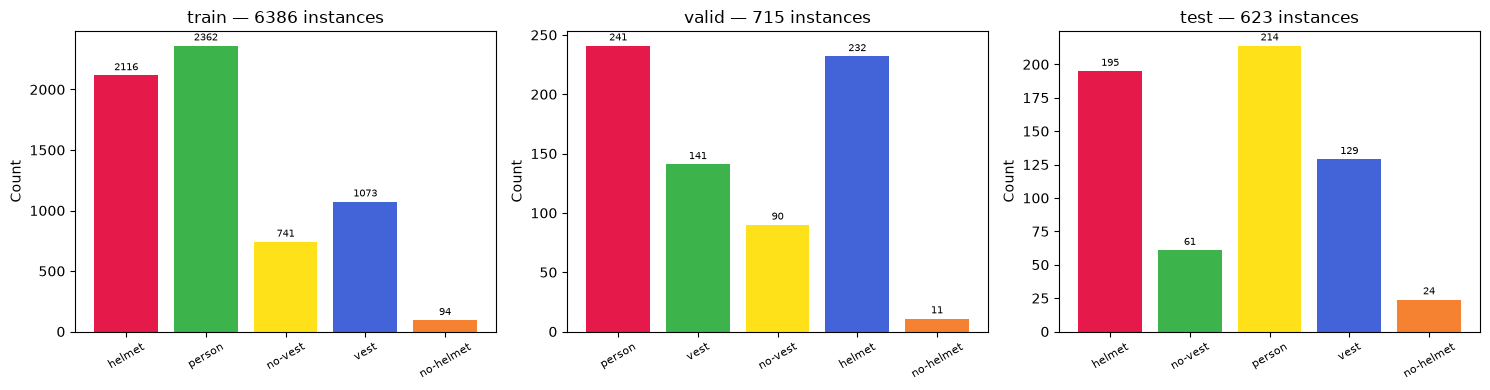

In [20]:
from collections import Counter

def class_distribution(split: str) -> Counter:
    lbl_dir = ROBOFLOW_DIR / split / "labels"
    counter = Counter()
    if not lbl_dir.exists():
        return counter
    for label_file in sorted(lbl_dir.glob("*.txt")):
        with open(label_file) as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                counter[class_names[cls_id]] += 1
    return counter


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "valid", "test"]):
    dist = class_distribution(split)
    if dist:
        classes = list(dist.keys())
        counts = list(dist.values())
        bars = ax.bar(classes, counts, color=COLORS[:len(classes)])
        ax.set_title(f"{split} — {sum(counts)} instances")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        for bar, c in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
                    str(c), ha="center", va="bottom", fontsize=7)
    else:
        ax.set_title(f"{split} — no labels")

plt.tight_layout()
plt.show()

## 5. Summary

| Split   | Images | Labels  |
|---------|--------|---------|
| Train   | 997    | 6386    |
| Valid   | 119    | 715     |
| Test    | 90     | 623     |

=== Class Distribution ===

**TRAIN**

helmet: 2116

person: 2362

no-vest: 741

vest: 1073

no-helmet: 94

**VALID**

person: 241

vest: 141

no-vest: 90

helmet: 232

no-helmet: 11

**TEST**

helmet: 195

person: 214

no-vest: 61

vest: 129

no-helmet: 24

**Classes**: person, helmet, no-helmet, safety-vest, no-vest

**Imbalance watch**: `no-helmet` / `no-vest` are minority classes — weighted loss and oversampling will be applied during training (see `algear.modeling.train`).